In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from funcoes.funcoes_feat_eng import *
# Comum -------------------------------------
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
# Regressão linear --------------------------
from sklearn.linear_model import LinearRegression
# Random Forest -----------------------------
from sklearn.ensemble import RandomForestRegressor
# XGBoost -----------------------------------
from xgboost import XGBRegressor
# Esemble -----------------------------------
from sklearn.ensemble import VotingRegressor

# Dados versão 1

In [3]:
df_v1 = pd.read_csv('../data/processed_v1/df_eng_feat_v1.csv', sep=';', encoding='utf-8-sig')
df_v1

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,yr_renovated,...,dist_seattle,bool_renovated_45,bool_renovated_15,price_log,sqft_lot_log,sqft_basement_log,sqft_lot15_log,lot_15_compare_log,living_15_compare_log,mean_price_zipcode_log
0,3,1.00,1180,1.0,0,0,3,7,1180,0,...,0.1211,0,0,12.309987,8.639588,0.000000,8.639588,0.693147,0.631591,12.646305
1,3,2.25,2570,2.0,0,0,3,7,2170,1991,...,0.1155,1,0,13.195616,8.887791,5.993961,8.941153,0.666803,0.924537,13.059331
2,2,1.00,770,1.0,0,0,3,6,770,0,...,0.1648,0,0,12.100718,9.210440,0.000000,8.995041,0.806654,0.249279,13.044361
3,4,3.00,1960,1.0,0,0,5,7,1050,0,...,0.1049,0,0,13.311331,8.517393,6.814543,8.517393,0.693147,0.892490,13.220741
4,3,2.00,1680,1.0,0,0,3,8,1680,0,...,0.2873,1,0,13.142168,8.997271,0.000000,8.923191,0.730876,0.659228,13.438060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,3,2.50,1530,3.0,0,0,3,8,1530,0,...,0.0941,1,0,12.793862,7.031741,0.000000,7.319865,0.559330,0.693147,13.279074
21608,4,2.50,2310,2.0,0,0,3,8,2310,0,...,0.1001,1,1,12.899222,8.668024,0.000000,8.881975,0.591889,0.816382,12.792426
21609,2,0.75,1020,2.0,0,0,3,7,1020,0,...,0.0351,1,0,12.904461,7.208600,0.000000,7.604894,0.514379,0.693147,13.295558
21610,3,2.50,1600,2.0,0,0,3,8,1600,0,...,0.2727,1,0,12.899222,7.778630,0.000000,7.160846,1.049247,0.758373,13.332611


## Finalizando os ajustes do dado

In [4]:
# Variáveis preditoras (X) e a variável alvo (y)
X_v1 = df_v1.drop(columns=['price_log'])
y_v1 = df_v1['price_log']

# Treino (80%) e Teste (20%)
Xv1_train, Xv1_test, yv1_train, yv1_test = train_test_split(
    X_v1, y_v1, 
    test_size=0.2, 
    random_state=42)

# Verificando as proporções na tela
print(f'Dados de Treino: {Xv1_train.shape[0]} linhas')
print(f'Dados de Teste: {Xv1_test.shape[0]} linhas')

Dados de Treino: 17289 linhas
Dados de Teste: 4323 linhas


In [5]:
obter_listas_tratamento(df_v1)

{'log': ['waterfront',
  'view',
  'yr_renovated',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'sqft_lot_more_living',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15',
  'lot_15_compare_log'],
 'capping': ['view',
  'grade',
  'estacao_Outono',
  'estacao_Inverno',
  'sqft_lot_more_living',
  'bool_renovated_15',
  'sqft_lot_log',
  'sqft_lot15_log',
  'lot_15_compare_log',
  'living_15_compare_log'],
 'extremos': ['bedrooms',
  'bathrooms',
  'sqft_living',
  'waterfront',
  'condition',
  'sqft_above',
  'yr_renovated',
  'sqft_living15',
  'final_de_semana',
  'fim_do_mes',
  'living_percent_total',
  'bath_per_bed',
  'bed_per_floor',
  'grade_x_condition',
  'bool_renovated',
  'living_more_than_lot',
  'dist_seattle',
  'price_log',
  'mean_price_zipcode_log'],
 'zeros': ['bedrooms',
  'bathrooms',
  'waterfront',
  'view',
  'yr_renovated',
  'dia_da_semana',
  'final_de_semana',
  'fim_do_mes',
  'dias_desde_inicio',
  'estacao_Primavera',
  

In [6]:
# Tratamento de capping
colunas_capping =  ['view',
  'grade',
  'estacao_Outono',
  'estacao_Inverno',
  'bool_renovated_15',
  'sqft_lot_log',
  'sqft_lot15_log',
  'lot_15_compare_log',
  'living_15_compare_log']

for col in colunas_capping:
    q1 = Xv1_train[col].quantile(0.25)
    q3 = Xv1_train[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    
    Xv1_train[col] = Xv1_train[col].clip(lower=limite_inf, upper=limite_sup)
    Xv1_test[col] = Xv1_test[col].clip(lower=limite_inf, upper=limite_sup)

### Regressão Linear

In [7]:
# Regressão Linear
lr_model = LinearRegression()
lr_model.fit(Xv1_train, yv1_train)

yv1_pred_train = lr_model.predict(Xv1_train)
yv1_pred_test = lr_model.predict(Xv1_test)

yv1_test_real = np.expm1(yv1_test)
yv1_pred_real = np.expm1(yv1_pred_test)

linear_r2_train_v1 = r2_score(yv1_train, yv1_pred_train)
linear_r2_test_v1 = r2_score(yv1_test, yv1_pred_test)
linear_mae_real_v1 = mean_absolute_error(yv1_test_real, yv1_pred_real)
linear_mse_real_v1 = mean_squared_error(yv1_test_real, yv1_pred_real)
linear_rmse_real_v1 = np.sqrt(linear_mse_real_v1)

regressao_linear_v1 = [linear_r2_train_v1, linear_r2_test_v1,linear_mae_real_v1,linear_mse_real_v1,linear_rmse_real_v1]

print('=== RESULTADOS DA REGRESSÃO LINEAR ===')
print(f'R² (Treino): {linear_r2_train_v1:.4f}')
print(f'R² (Teste) : {linear_r2_test_v1:.4f}')
print(f'Erro Médio Absoluto (MAE): U$ {linear_mae_real_v1:,.2f}')
print(f'Erro Quadrático Médio (MSE): {linear_mse_real_v1:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {linear_rmse_real_v1:,.2f}')

=== RESULTADOS DA REGRESSÃO LINEAR ===
R² (Treino): 0.8591
R² (Teste) : 0.8573
Erro Médio Absoluto (MAE): U$ 87,854.56
Erro Quadrático Médio (MSE): 27,264,878,909.37
Raiz do Erro Quadrático Médio (RMSE): U$ 165,120.80


### RandomForest

In [8]:
# Random Forest (Padrão)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(Xv1_train, yv1_train)

y_pred_train = rf_model.predict(Xv1_train)
y_pred_test = rf_model.predict(Xv1_test)

yv1_test_real = np.expm1(yv1_test)
y_pred_real = np.expm1(y_pred_test)

randomforestpadrao_r2_train_v1 = r2_score(yv1_train, y_pred_train)
randomforestpadrao_r2_test_v1 = r2_score(yv1_test, y_pred_test)
randomforestpadrao_mae_real_v1 = mean_absolute_error(yv1_test_real, y_pred_real)
randomforestpadrao_mse_real_v1 = mean_squared_error(yv1_test_real, y_pred_real)
randomforestpadrao_rmse_real_v1 = np.sqrt(randomforestpadrao_mse_real_v1)

randomforest_padrao_v1 = [randomforestpadrao_r2_train_v1, randomforestpadrao_r2_test_v1, randomforestpadrao_mae_real_v1, randomforestpadrao_mse_real_v1, randomforestpadrao_rmse_real_v1]

print('=== RESULTADOS DO RANDOM FOREST ===')
print(f'R² (Treino): {randomforestpadrao_r2_train_v1:.4f}')
print(f'R² (Teste) : {randomforestpadrao_r2_test_v1:.4f}')
print(f'Erro Médio Absoluto (MAE): U$ {randomforestpadrao_mae_real_v1:,.2f}')
print(f'Erro Quadrático Médio (MSE): {randomforestpadrao_mse_real_v1:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {randomforestpadrao_rmse_real_v1:,.2f}')

=== RESULTADOS DO RANDOM FOREST ===
R² (Treino): 0.9838
R² (Teste) : 0.8854
Erro Médio Absoluto (MAE): U$ 74,362.12
Erro Quadrático Médio (MSE): 20,209,268,380.95
Raiz do Erro Quadrático Médio (RMSE): U$ 142,159.31


In [9]:
# Definir o espaço de parâmetros específicos para Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],           
    'min_samples_split': [2, 5, 10],           
    'min_samples_leaf': [1, 2, 4],             
    'max_features': ['sqrt', 'log2', None]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Configurar o RandomizedSearch
tuning_rf = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist_rf, 
    n_iter=15, ##TROCAR PARA GRIDSEARCHCV??
    scoring='r2', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

# Rodar a busca
tuning_rf.fit(Xv1_train, yv1_train)

print('=== MELHORES PARÂMETROS DO RANDOM FOREST ===')
print(tuning_rf.best_params_)

=== MELHORES PARÂMETROS DO RANDOM FOREST ===
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15}


In [10]:
# Novo Random Forest (Otimizado)
melhor_rf = tuning_rf.best_estimator_

y_pred_rf_best_log = melhor_rf.predict(Xv1_test)
y_pred_rf_best_real = np.expm1(y_pred_rf_best_log)
yv1_test_real = np.expm1(yv1_test)
y_pred_rf_best_train_log = melhor_rf.predict(Xv1_train)

randomforestotimizado_r2_train_v1 = r2_score(yv1_train, y_pred_rf_best_train_log)
randomforestotimizado_r2_rf_best_v1 = r2_score(yv1_test, y_pred_rf_best_log)
randomforestotimizado_mae_rf_best_v1 = mean_absolute_error(yv1_test_real, y_pred_rf_best_real)
randomforestotimizado_mse_rf_best_v1 = mean_squared_error(yv1_test_real, y_pred_rf_best_real)
randomforestotimizado_rmse_rf_best_v1 = np.sqrt(randomforestotimizado_mse_rf_best_v1)

randomforestotimizado_v1 = [randomforestotimizado_r2_train_v1, randomforestotimizado_r2_rf_best_v1, randomforestotimizado_mae_rf_best_v1, randomforestotimizado_mse_rf_best_v1, randomforestotimizado_rmse_rf_best_v1]

print('=== NOVO RANDOM FOREST (OTIMIZADO) ===')
print(f'R² (Treino): {randomforestotimizado_r2_train_v1:.4f}')
print(f'Novo R² (Teste) : {randomforestotimizado_r2_rf_best_v1:.4f}')
print(f'Novo Erro (MAE) : U$ {randomforestotimizado_mae_rf_best_v1:,.2f}')
print(f'Novo Erro Quadrático Médio (MSE): {randomforestotimizado_mse_rf_best_v1:,.2f}')
print(f'Novo Raiz do Erro Quadrático Médio (RMSE): U$ {randomforestotimizado_rmse_rf_best_v1:,.2f}')

=== NOVO RANDOM FOREST (OTIMIZADO) ===
R² (Treino): 0.9721
Novo R² (Teste) : 0.8855
Novo Erro (MAE) : U$ 74,568.56
Novo Erro Quadrático Médio (MSE): 20,055,554,969.44
Novo Raiz do Erro Quadrático Médio (RMSE): U$ 141,617.64


### XGBoost

In [11]:
# XGBoost (Padrão)
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.08, 
    max_depth=6, 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(Xv1_train, yv1_train)

y_pred_train = xgb_model.predict(Xv1_train)
y_pred_test = xgb_model.predict(Xv1_test)

yv1_test_real = np.expm1(yv1_test)
y_pred_real = np.expm1(y_pred_test)

xgboost_native_r2_train_v1 = r2_score(yv1_train, y_pred_train)
xgboost_native_r2_test_v1 = r2_score(yv1_test, y_pred_test)
xgboost_native_mae_real_v1 = mean_absolute_error(yv1_test_real, y_pred_real)
xgboost_native_mse_real_v1 = mean_squared_error(yv1_test_real, y_pred_real)
xgboost_native_rmse_real_v1 = np.sqrt(xgboost_native_mse_real_v1)

xgboost_native_v1 = [xgboost_native_r2_train_v1, xgboost_native_r2_test_v1, xgboost_native_mae_real_v1, xgboost_native_mse_real_v1, xgboost_native_rmse_real_v1]

print('=== RESULTADOS DO XGBOOST ===')
print(f'R² (Treino): {xgboost_native_r2_train_v1:.4f}')
print(f'R² (Teste) : {xgboost_native_r2_test_v1:.4f}')
print(f'Erro Médio Absoluto (MAE): U$ {xgboost_native_mae_real_v1:,.2f}')
print(f'Erro Quadrático Médio (MSE): {xgboost_native_mse_real_v1:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {xgboost_native_rmse_real_v1:,.2f}')

=== RESULTADOS DO XGBOOST ===
R² (Treino): 0.9271
R² (Teste) : 0.8954
Erro Médio Absoluto (MAE): U$ 69,473.86
Erro Quadrático Médio (MSE): 15,794,991,112.32
Raiz do Erro Quadrático Médio (RMSE): U$ 125,678.13


In [12]:
# Busca pelos melhores parâmetros
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Teste de combinações aleatórias (velocidade > GridSearch)
tuning = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_dist, 
    n_iter=15,
    scoring='r2', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

tuning.fit(Xv1_train, yv1_train)
print('Melhores parâmetros encontrados:', tuning.best_params_)


Melhores parâmetros encontrados: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [13]:
# XGBoost (Otimizado)
melhor_xgb = tuning.best_estimator_

y_pred_best_log = melhor_xgb.predict(Xv1_test)
y_pred_best_real = np.expm1(y_pred_best_log)
yv1_test_real = np.expm1(yv1_test)
y_pred_best_train_log = melhor_xgb.predict(Xv1_train)

xgboost_orimizado_r2_best_train_v1 = r2_score(yv1_train, y_pred_best_train_log)
xgboost_orimizado_r2_best_v1 = r2_score(yv1_test, y_pred_best_log)
xgboost_orimizado_mae_best_v1 = mean_absolute_error(yv1_test_real, y_pred_best_real)
xgboost_orimizado_mse_best_v1 = mean_squared_error(yv1_test_real, y_pred_best_real)
xgboost_orimizado_rmse_best_v1 = np.sqrt(xgboost_orimizado_mse_best_v1)

xgboost_orimizado_v1 = [xgboost_orimizado_r2_best_train_v1, xgboost_orimizado_r2_best_v1, xgboost_orimizado_mae_best_v1, xgboost_orimizado_mse_best_v1, xgboost_orimizado_rmse_best_v1]

print('=== NOVO MODELO XGBOOST (OTIMIZADO) ===')
print(f'Novo R² (Treino) : {xgboost_orimizado_r2_best_train_v1:.4f}')
print(f'Novo R² (Teste) : {xgboost_orimizado_r2_best_v1:.4f}')
print(f'Novo Erro (MAE) : U$ {xgboost_orimizado_mae_best_v1:,.2f}')
print(f'Novo Erro Quadrático Médio (MSE): {xgboost_orimizado_mse_best_v1:,.2f}')
print(f'Novo Raiz do Erro Quadrático Médio (RMSE): U$ {xgboost_orimizado_rmse_best_v1:,.2f}')

=== NOVO MODELO XGBOOST (OTIMIZADO) ===
Novo R² (Treino) : 0.9581
Novo R² (Teste) : 0.9008
Novo Erro (MAE) : U$ 67,014.44
Novo Erro Quadrático Médio (MSE): 15,398,802,326.20
Novo Raiz do Erro Quadrático Médio (RMSE): U$ 124,091.91


### Esemble

In [14]:
# Ensemble (Voting)
ensemble_ponderado = VotingRegressor(estimators=[
    ('xgb_otimizado', melhor_xgb),
    ('random_forest', rf_model)],
    weights=[0.9, 0.1])

ensemble_ponderado.fit(Xv1_train, yv1_train)

y_pred_weighted_log = ensemble_ponderado.predict(Xv1_test)
y_pred_weighted_real = np.expm1(y_pred_weighted_log)
y_pred_weighted_train_log = ensemble_ponderado.predict(Xv1_train)

ensemble_r2_weighted_train_v1 = r2_score(yv1_train, y_pred_weighted_train_log)
ensemble_r2_weighted_v1 = r2_score(yv1_test, y_pred_weighted_log)
ensemble_mae_weighted_v1 = mean_absolute_error(yv1_test_real, y_pred_weighted_real)
ensemble_mse_weighted_v1 = mean_squared_error(yv1_test_real, y_pred_weighted_real)
ensemble_rmse_weighted_v1 = np.sqrt(ensemble_mse_weighted_v1)

ensemble_v1 = [ensemble_r2_weighted_train_v1, ensemble_r2_weighted_v1, ensemble_mae_weighted_v1, ensemble_mse_weighted_v1, ensemble_rmse_weighted_v1]

print('=== RESULTADOS DO ENSEMBLE (VOTING) ===')
print(f'R² (Treino): {ensemble_r2_weighted_train_v1:.4f}')
print(f'R² (Teste) : {ensemble_r2_weighted_v1:.4f}')
print(f'Erro (MAE) : U$ {ensemble_mae_weighted_v1:,.2f}')
print(f'Erro Quadrático Médio (MSE): {ensemble_mse_weighted_v1:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {ensemble_rmse_weighted_v1:,.2f}')

=== RESULTADOS DO ENSEMBLE (VOTING) ===
R² (Treino): 0.9619
R² (Teste) : 0.9008
Erro (MAE) : U$ 67,105.24
Erro Quadrático Médio (MSE): 15,516,389,423.91
Raiz do Erro Quadrático Médio (RMSE): U$ 124,564.80


## Feature importance

In [15]:
# Tabela comparativa
metricas_modelos_v1 = {
    'Regressão Linear': regressao_linear_v1,
    'Random Forest (Padrão)': randomforest_padrao_v1,
    'Random Forest (Otimizado)': randomforestotimizado_v1,
    'XGBoost (Nativo)': xgboost_native_v1,
    'XGBoost (Otimizado)': xgboost_orimizado_v1,
    'Ensemble (Voting)': ensemble_v1}

colunas = ['R² (Treino)', 'R² (Teste)', 'MAE (US$)', 'MSE (US$)', 'RMSE (US$)']

tabela_comparativa = pd.DataFrame.from_dict(metricas_modelos_v1, orient='index', columns=colunas)

tabela_comparativa = tabela_comparativa.reset_index().rename(columns={'index': 'Modelo'})

tabela_comparativa = tabela_comparativa.sort_values(by='MAE (US$)').reset_index(drop=True)
tabela_comparativa

,Modelo,R² (Treino),R² (Teste),MAE (US$),MSE (US$),RMSE (US$)
0,XGBoost (Otimizado),0.958052,0.900787,67014.438904,1.539880e+10,124091.910801
1,Ensemble (Voting),0.961902,0.900827,67105.240270,1.551639e+10,124564.800100
2,XGBoost (Nativo),0.927118,0.895385,69473.862288,1.579499e+10,125678.125035
3,Random Forest (Padrão),0.983786,0.885382,74362.116106,2.020927e+10,142159.306347
4,Random Forest (Otimizado),0.972129,0.885499,74568.562681,2.005555e+10,141617.636506
5,Regressão Linear,0.859091,0.857251,87854.561567,2.726488e+10,165120.800959


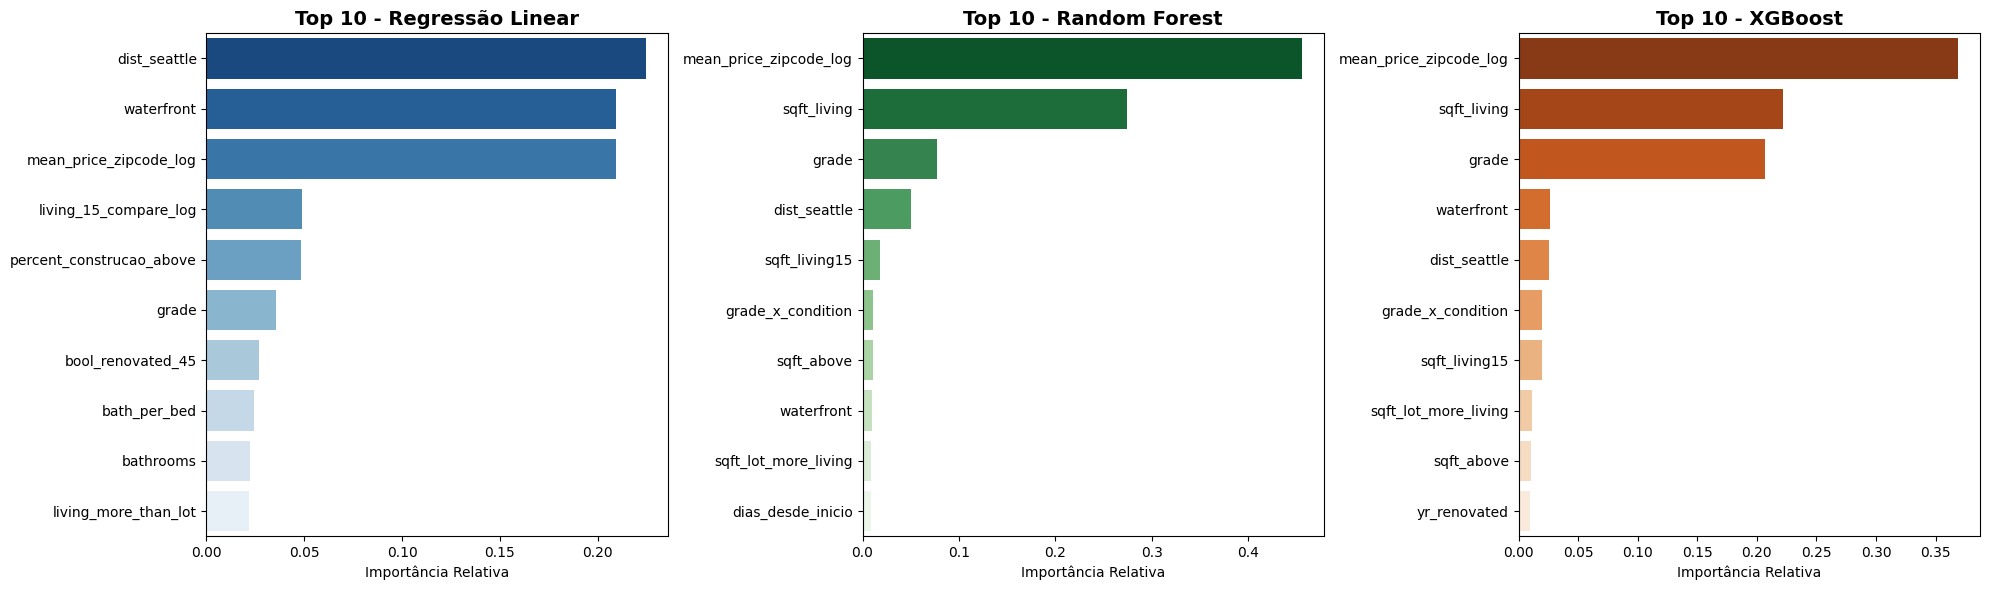

In [16]:
# Extrair as importâncias de cada modelo
recursos = Xv1_train.columns

# Regressão Linear
coef_absolutos = np.abs(lr_model.coef_)
importancia_lr = coef_absolutos / np.sum(coef_absolutos)

# Random Forest e XGBoost
importancia_rf = rf_model.feature_importances_
importancia_xgb = xgb_model.feature_importances_

# DF Comparativo
df_importancias = pd.DataFrame({
    'Variável': recursos,
    'Regressão Linear': importancia_lr,
    'Random Forest': importancia_rf,
    'XGBoost': importancia_xgb
})

# Config de plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
modelos = ['Regressão Linear', 'Random Forest', 'XGBoost']
paletas = ['Blues_r', 'Greens_r', 'Oranges_r']

for i, modelo in enumerate(modelos):
    # Top 10
    df_top10 = df_importancias[['Variável', modelo]].sort_values(by=modelo, ascending=False).head(10)
    
    sns.barplot(
        data=df_top10, 
        y='Variável', 
        x=modelo, 
        ax=axes[i], 
        palette=paletas[i],
        hue='Variável',
        legend=False
    )
    axes[i].set_title(f'Top 10 - {modelo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Importância Relativa')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

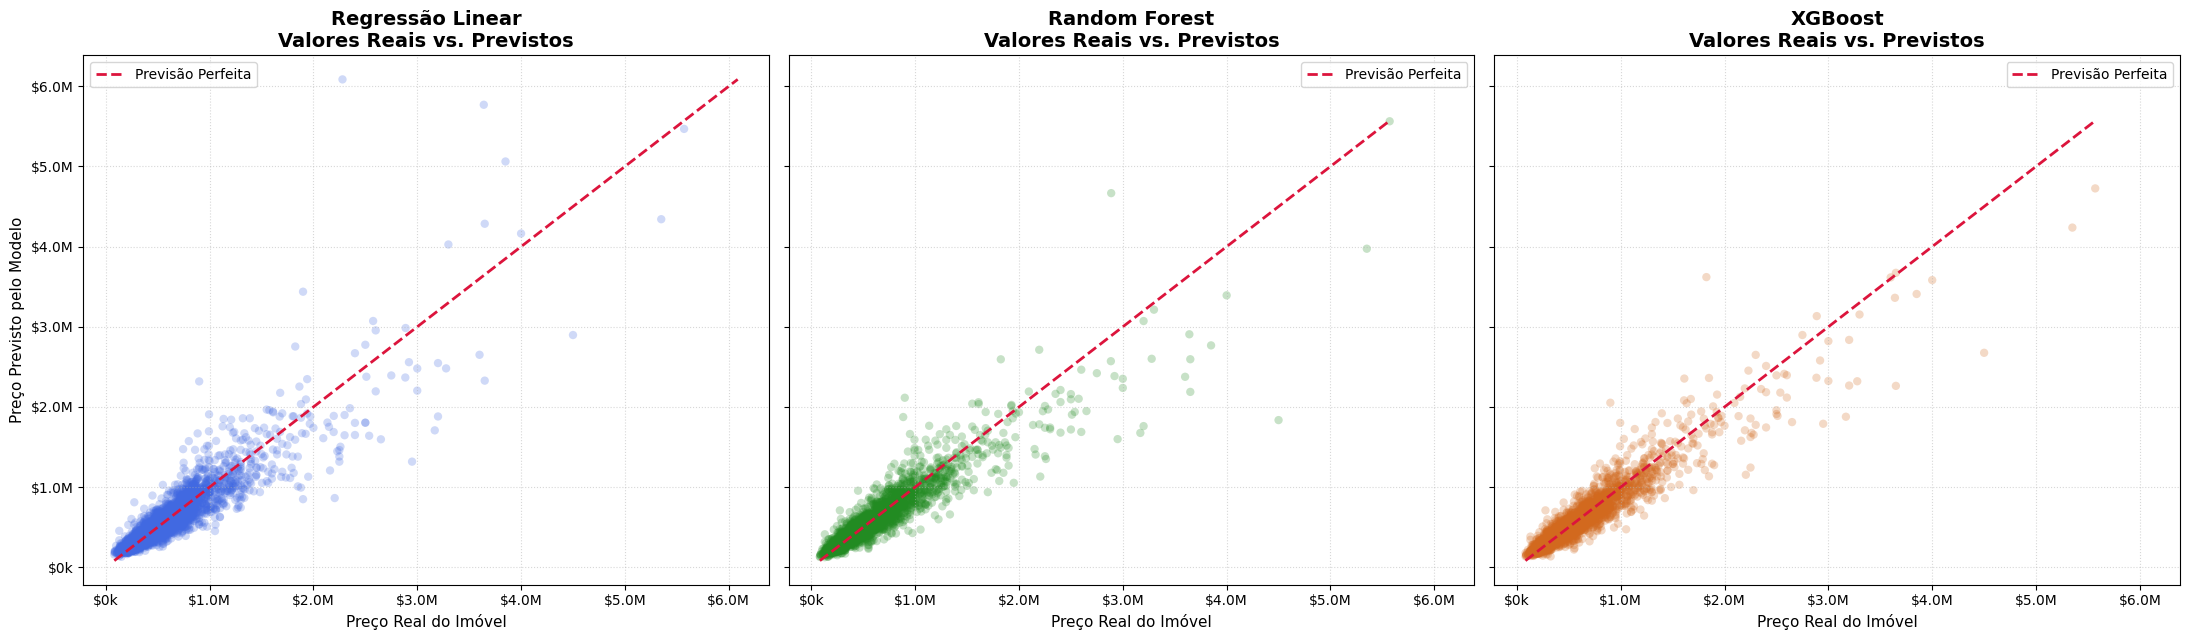

In [ ]:
# V1
# Gerar as predições de todos os modelos na escala monetária real
yv1_test_real = np.expm1(yv1_test)
y_pred_lr = np.expm1(lr_model.predict(Xv1_test))
y_pred_rf = np.expm1(rf_model.predict(Xv1_test))
y_pred_xgb = np.expm1(xgb_model.predict(Xv1_test))

# Config de plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True, sharex=True)

dados_plot = [
    ('Regressão Linear', y_pred_lr, 'royalblue'),
    ('Random Forest', y_pred_rf, 'forestgreen'),
    ('XGBoost', y_pred_xgb, 'chocolate')
]

for i, (nome, y_pred, cor) in enumerate(dados_plot):
    # Pontos reais vs Previstos
    sns.scatterplot(
        x=yv1_test_real, 
        y=y_pred, 
        ax=axes[i], 
        color=cor, 
        alpha=0.25, 
        edgecolor='none'
    )
    
    # Previsão perfeita
    limite_max = max(yv1_test_real.max(), y_pred.max())
    limite_min = min(yv1_test_real.min(), y_pred.min())
    axes[i].plot([limite_min, limite_max], [limite_min, limite_max], color='crimson', linestyle='--', linewidth=2, label='Previsão Perfeita')
    
    # Títulos e formatações
    axes[i].set_title(f'{nome}\nValores Reais vs. Previstos', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Preço Real do Imóvel', fontsize=11)
    if i == 0:
        axes[i].set_ylabel('Preço Previsto pelo Modelo', fontsize=11)
    
    # Formatação dos valores
    formatter = plt.FuncFormatter(lambda val, pos: f'${val*1e-6:.1f}M' if val >= 1e6 else f'${val*1e-3:.0f}k')
    axes[i].xaxis.set_major_formatter(formatter)
    axes[i].yaxis.set_major_formatter(formatter)
    
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

#### Salvando o modelo campeão

In [18]:
import json
import joblib 

caminho_pasta = '../models/v1/'
os.makedirs(caminho_pasta, exist_ok=True)

xgb_model = tuning.best_estimator_ 
caminho_modelo = os.path.join(caminho_pasta, 'modelo_regressao_v1.pkl')

joblib.dump(xgb_model, caminho_modelo)
print(f'Modelo salvo com sucesso em: {caminho_modelo}')

metricas_v1 = {
    'modelo': 'XGBoost_Otimizado',
    'r2_score': xgboost_orimizado_r2_best_v1,
    'mae_usd': xgboost_orimizado_mae_best_v1,
    'mse_usd': xgboost_orimizado_mse_best_v1,
    'rmse_usd': xgboost_orimizado_rmse_best_v1,
    'parametros': 'learning_rate=0.05, max_depth=6'}

caminho_metricas = os.path.join(caminho_pasta, 'metricas_v1.json')

with open(caminho_metricas, 'w', encoding='utf-8') as f:
    json.dump(metricas_v1, f, indent=4)
    
print(f'Métricas salvas com sucesso em: {caminho_metricas}')

Modelo salvo com sucesso em: ../models/v1/modelo_regressao_v1.pkl
Métricas salvas com sucesso em: ../models/v1/metricas_v1.json


# Dados Versão 2

In [ ]:
df_v2 = pd.read_csv('../data/processed_v2/df_eng_feat_v2.csv', sep=';', encoding='utf-8-sig')
df_v2

In [20]:
# Variáveis preditoras (X) e a variável alvo (y)
X = df_v2.drop(columns=['price_log'])
y = df_v2['price_log']

# Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42)

# Verificando as proporções na tela
print(f'Dados de Treino: {X_train.shape[0]} linhas')
print(f'Dados de Teste: {X_test.shape[0]} linhas')

Dados de Treino: 17276 linhas
Dados de Teste: 4320 linhas


In [21]:
# Capping
colunas_capping =  ['view',
  'grade',
  'estacao_Outono',
  'estacao_Inverno',
  'bool_renovated_15',
  'sqft_lot_log',
  'sqft_lot15_log',
  'lot_15_compare_log',
  'living_15_compare_log']

for col in colunas_capping:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    
    X_train[col] = X_train[col].clip(lower=limite_inf, upper=limite_sup)
    X_test[col] = X_test[col].clip(lower=limite_inf, upper=limite_sup)

## Regressão linear

In [22]:
# Regressão Linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

linear_r2_train = r2_score(y_train, y_pred_train)
linear_r2_test = r2_score(y_test, y_pred_test)
linear_mae_real = mean_absolute_error(y_test_real, y_pred_real)
linear_mse_real = mean_squared_error(y_test_real, y_pred_real)
linear_rmse_real = np.sqrt(linear_mse_real)

regressao_linear = [linear_r2_train, linear_r2_test,linear_mae_real,linear_mse_real,linear_rmse_real]

print('=== RESULTADOS DA REGRESSÃO LINEAR ===')
print(f'R² (Treino): {linear_r2_train:.4f}')
print(f'R² (Teste) : {linear_r2_test:.4f}')
print(f'Erro Médio Absoluto (MAE): U$ {linear_mae_real:,.2f}')
print(f'Erro Quadrático Médio (MSE): {linear_mse_real:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {linear_rmse_real:,.2f}')

=== RESULTADOS DA REGRESSÃO LINEAR ===
R² (Treino): 0.8766
R² (Teste) : 0.8688
Erro Médio Absoluto (MAE): U$ 77,157.89
Erro Quadrático Médio (MSE): 17,670,026,683.86
Raiz do Erro Quadrático Médio (RMSE): U$ 132,928.65


## RandomForest

In [23]:
# Random Forest (Padrão)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

randomforestpadrao_r2_train = r2_score(y_train, y_pred_train)
randomforestpadrao_r2_test = r2_score(y_test, y_pred_test)
randomforestpadrao_mae_real = mean_absolute_error(y_test_real, y_pred_real)
randomforestpadrao_mse_real = mean_squared_error(y_test_real, y_pred_real)
randomforestpadrao_rmse_real = np.sqrt(randomforestpadrao_mse_real)

randomforest_padrao = [randomforestpadrao_r2_train, randomforestpadrao_r2_test, randomforestpadrao_mae_real, randomforestpadrao_mse_real, randomforestpadrao_rmse_real]

print('=== RESULTADOS DO RANDOM FOREST ===')
print(f'R² (Treino): {randomforestpadrao_r2_train:.4f}')
print(f'R² (Teste) : {randomforestpadrao_r2_test:.4f}')
print(f'Erro Médio Absoluto (MAE): U$ {randomforestpadrao_mae_real:,.2f}')
print(f'Erro Quadrático Médio (MSE): {randomforestpadrao_mse_real:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {randomforestpadrao_rmse_real:,.2f}')

=== RESULTADOS DO RANDOM FOREST ===
R² (Treino): 0.9850
R² (Teste) : 0.8940
Erro Médio Absoluto (MAE): U$ 67,692.16
Erro Quadrático Médio (MSE): 17,138,007,228.44
Raiz do Erro Quadrático Médio (RMSE): U$ 130,912.21


In [24]:
# Definir o espaço de parâmetros específicos para Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],           
    'min_samples_split': [2, 5, 10],           
    'min_samples_leaf': [1, 2, 4],             
    'max_features': ['sqrt', 'log2', None]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Configurar o RandomizedSearch
tuning_rf = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist_rf, 
    n_iter=15, ##TROCAR PARA GRIDSEARCHCV??
    scoring='r2', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

# Rodar a busca
tuning_rf.fit(X_train, y_train)

print('=== MELHORES PARÂMETROS DO RANDOM FOREST ===')
print(tuning_rf.best_params_)

=== MELHORES PARÂMETROS DO RANDOM FOREST ===
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [25]:
# Novo Random Forest (Otimizado)
melhor_rf = tuning_rf.best_estimator_

y_pred_rf_best_log = melhor_rf.predict(X_test)
y_pred_rf_best_real = np.expm1(y_pred_rf_best_log)
y_test_real = np.expm1(y_test)
y_pred_rf_best_train_log = melhor_rf.predict(X_train)

randomforestotimizado_r2_train = r2_score(y_train, y_pred_rf_best_train_log)
randomforestotimizado_r2_rf_best = r2_score(y_test, y_pred_rf_best_log)
randomforestotimizado_mae_rf_best = mean_absolute_error(y_test_real, y_pred_rf_best_real)
randomforestotimizado_mse_rf_best = mean_squared_error(y_test_real, y_pred_rf_best_real)
randomforestotimizado_rmse_rf_best = np.sqrt(randomforestotimizado_mse_rf_best)

randomforestotimizado = [randomforestotimizado_r2_train, randomforestotimizado_r2_rf_best, randomforestotimizado_mae_rf_best, randomforestotimizado_mse_rf_best, randomforestotimizado_rmse_rf_best]

print('=== NOVO RANDOM FOREST (OTIMIZADO) ===')
print(f'R² (Treino): {randomforestotimizado_r2_train:.4f}')
print(f'Novo R² (Teste) : {randomforestotimizado_r2_rf_best:.4f}')
print(f'Novo Erro (MAE) : U$ {randomforestotimizado_mae_rf_best:,.2f}')
print(f'Novo Erro Quadrático Médio (MSE): {randomforestotimizado_mse_rf_best:,.2f}')
print(f'Novo Raiz do Erro Quadrático Médio (RMSE): U$ {randomforestotimizado_rmse_rf_best:,.2f}')

=== NOVO RANDOM FOREST (OTIMIZADO) ===
R² (Treino): 0.9844
Novo R² (Teste) : 0.8984
Novo Erro (MAE) : U$ 65,717.83
Novo Erro Quadrático Médio (MSE): 17,446,606,840.16
Novo Raiz do Erro Quadrático Médio (RMSE): U$ 132,085.60


## XGBoost

In [26]:
# XGBoost (Padrão)
xgb_model = XGBRegressor(
    n_estimators=100, 
    learning_rate=0.08, 
    max_depth=6, 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_test)

xgboost_native_r2_train = r2_score(y_train, y_pred_train)
xgboost_native_r2_test = r2_score(y_test, y_pred_test)
xgboost_native_mae_real = mean_absolute_error(y_test_real, y_pred_real)
xgboost_native_mse_real = mean_squared_error(y_test_real, y_pred_real)
xgboost_native_rmse_real = np.sqrt(xgboost_native_mse_real)

xgboost_native = [xgboost_native_r2_train, xgboost_native_r2_test, xgboost_native_mae_real, xgboost_native_mse_real, xgboost_native_rmse_real,]

print('=== RESULTADOS DO XGBOOST ===')
print(f'R² (Treino): {xgboost_native_r2_train:.4f}')
print(f'R² (Teste) : {xgboost_native_r2_test:.4f}')
print(f'Erro Médio Absoluto (MAE): U$ {xgboost_native_mae_real:,.2f}')
print(f'Erro Quadrático Médio (MSE): {xgboost_native_mse_real:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {xgboost_native_rmse_real:,.2f}')

=== RESULTADOS DO XGBOOST ===
R² (Treino): 0.9356
R² (Teste) : 0.9034
Erro Médio Absoluto (MAE): U$ 63,243.64
Erro Quadrático Médio (MSE): 14,524,222,613.25
Raiz do Erro Quadrático Médio (RMSE): U$ 120,516.48


In [27]:
# Busca pelos melhores parâmetros
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Teste de combinações aleatórias (velocidade > GridSearch)
tuning = RandomizedSearchCV(
    estimator=xgb, 
    param_distributions=param_dist, 
    n_iter=15,
    scoring='r2', 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

tuning.fit(X_train, y_train)
print('Melhores parâmetros encontrados:', tuning.best_params_)


Melhores parâmetros encontrados: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [28]:
# XGBoost (Otimizado)
melhor_xgb = tuning.best_estimator_

y_pred_best_log = melhor_xgb.predict(X_test)
y_pred_best_real = np.expm1(y_pred_best_log)
y_test_real = np.expm1(y_test)
y_pred_best_train_log = melhor_xgb.predict(X_train)

xgboost_orimizado_r2_best_train = r2_score(y_train, y_pred_best_train_log)
xgboost_orimizado_r2_best = r2_score(y_test, y_pred_best_log)
xgboost_orimizado_mae_best = mean_absolute_error(y_test_real, y_pred_best_real)
xgboost_orimizado_mse_best = mean_squared_error(y_test_real, y_pred_best_real)
xgboost_orimizado_rmse_best = np.sqrt(xgboost_orimizado_mse_best)

xgboost_orimizado = [xgboost_orimizado_r2_best_train, xgboost_orimizado_r2_best, xgboost_orimizado_mae_best, xgboost_orimizado_mse_best, xgboost_orimizado_rmse_best]

print('=== NOVO MODELO XGBOOST (OTIMIZADO) ===')
print(f'Novo R² (Treino) : {xgboost_orimizado_r2_best_train:.4f}')
print(f'Novo R² (Teste) : {xgboost_orimizado_r2_best:.4f}')
print(f'Novo Erro (MAE) : U$ {xgboost_orimizado_mae_best:,.2f}')
print(f'Novo Erro Quadrático Médio (MSE): {xgboost_orimizado_mse_best:,.2f}')
print(f'Novo Raiz do Erro Quadrático Médio (RMSE): U$ {xgboost_orimizado_rmse_best:,.2f}')

=== NOVO MODELO XGBOOST (OTIMIZADO) ===
Novo R² (Treino) : 0.9640
Novo R² (Teste) : 0.9093
Novo Erro (MAE) : U$ 60,627.38
Novo Erro Quadrático Médio (MSE): 13,824,602,817.36
Novo Raiz do Erro Quadrático Médio (RMSE): U$ 117,578.07


## Esemble

In [29]:
# Ensemble (Voting)
ensemble_ponderado = VotingRegressor(estimators=[
    ('xgb_otimizado', melhor_xgb),
    ('random_forest', rf_model)],
    weights=[0.9, 0.1])

ensemble_ponderado.fit(X_train, y_train)

y_pred_weighted_log = ensemble_ponderado.predict(X_test)
y_pred_weighted_real = np.expm1(y_pred_weighted_log)
y_pred_weighted_train_log = ensemble_ponderado.predict(X_train)

ensemble_r2_weighted_train = r2_score(y_train, y_pred_weighted_train_log)
ensemble_r2_weighted = r2_score(y_test, y_pred_weighted_log)
ensemble_mae_weighted = mean_absolute_error(y_test_real, y_pred_weighted_real)
ensemble_mse_weighted = mean_squared_error(y_test_real, y_pred_weighted_real)
ensemble_rmse_weighted = np.sqrt(ensemble_mse_weighted)

ensemble = [ensemble_r2_weighted_train, ensemble_r2_weighted, ensemble_mae_weighted, ensemble_mse_weighted, ensemble_rmse_weighted]

print('=== RESULTADOS DO ENSEMBLE (VOTING) ===')
print(f'R² (Treino): {ensemble_r2_weighted_train:.4f}')
print(f'R² (Teste) : {ensemble_r2_weighted:.4f}')
print(f'Erro (MAE) : U$ {ensemble_mae_weighted:,.2f}')
print(f'Erro Quadrático Médio (MSE): {ensemble_mse_weighted:,.2f}')
print(f'Raiz do Erro Quadrático Médio (RMSE): U$ {ensemble_rmse_weighted:,.2f}')

=== RESULTADOS DO ENSEMBLE (VOTING) ===
R² (Treino): 0.9672
R² (Teste) : 0.9091
Erro (MAE) : U$ 60,849.50
Erro Quadrático Médio (MSE): 13,916,725,472.13
Raiz do Erro Quadrático Médio (RMSE): U$ 117,969.17


## Feature importance

In [30]:
# Tabela comparativa
metricas_modelos = {
    'Regressão Linear': regressao_linear,
    'Random Forest (Padrão)': randomforest_padrao,
    'Random Forest (Otimizado)': randomforestotimizado,
    'XGBoost (Nativo)': xgboost_native,
    'XGBoost (Otimizado)': xgboost_orimizado,
    'Ensemble (Voting)': ensemble}

colunas = ['R² (Treino)', 'R² (Teste)', 'MAE (US$)', 'MSE (US$)', 'RMSE (US$)']

tabela_comparativa = pd.DataFrame.from_dict(metricas_modelos, orient='index', columns=colunas)

tabela_comparativa = tabela_comparativa.reset_index().rename(columns={'index': 'Modelo'})

tabela_comparativa = tabela_comparativa.sort_values(by='MAE (US$)').reset_index(drop=True)
tabela_comparativa

,Modelo,R² (Treino),R² (Teste),MAE (US$),MSE (US$),RMSE (US$)
0,XGBoost (Otimizado),0.964025,0.909329,60627.384596,1.382460e+10,117578.071159
1,Ensemble (Voting),0.967178,0.909073,60849.495336,1.391673e+10,117969.171702
2,XGBoost (Nativo),0.935583,0.903358,63243.635995,1.452422e+10,120516.482745
3,Random Forest (Otimizado),0.984431,0.898403,65717.825316,1.744661e+10,132085.604212
4,Random Forest (Padrão),0.985016,0.893975,67692.155520,1.713801e+10,130912.211915
5,Regressão Linear,0.876593,0.868847,77157.888221,1.767003e+10,132928.652607


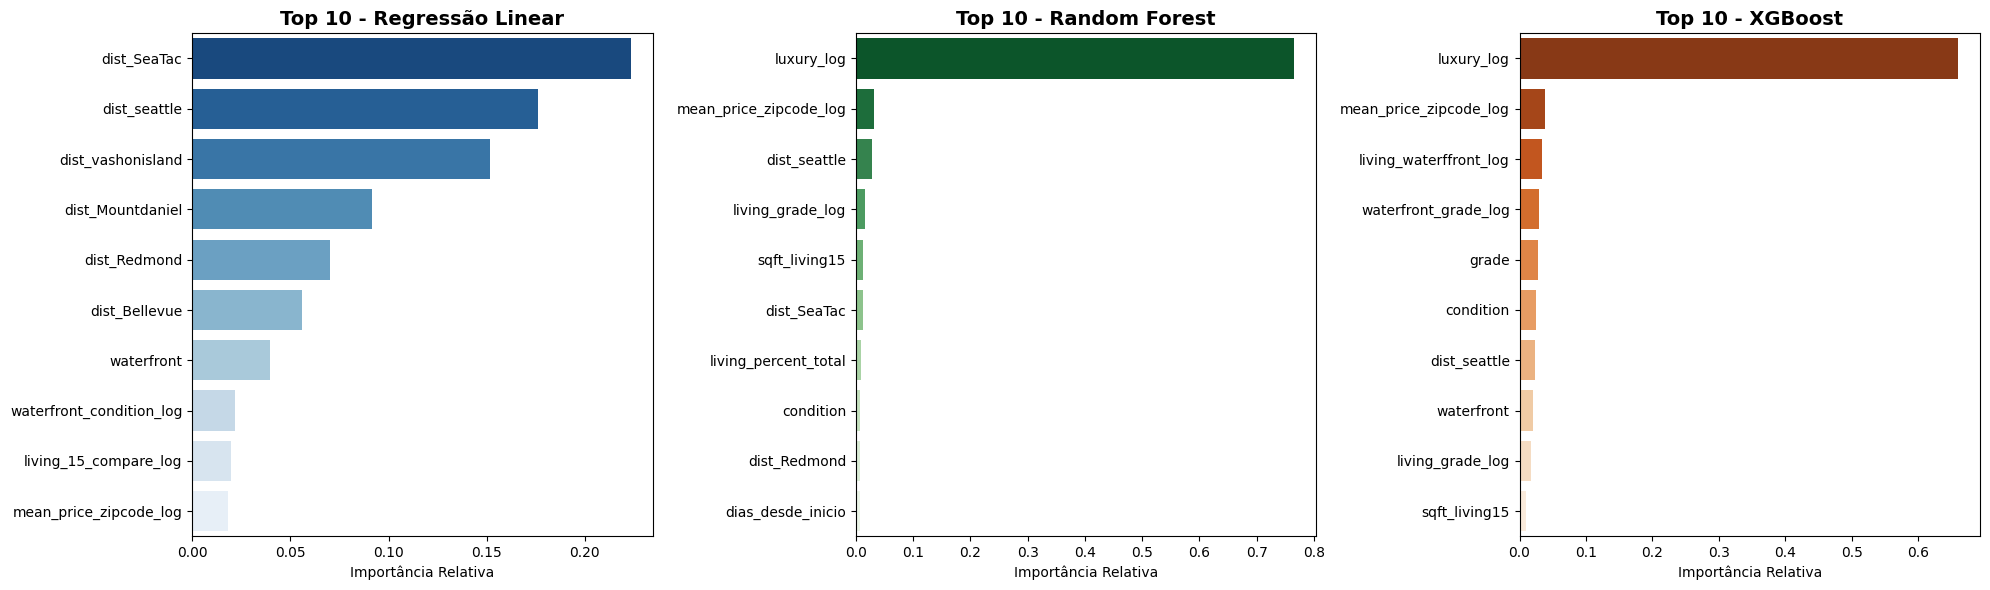

In [31]:
# Extrair as importâncias de cada modelo
recursos = X_train.columns

# Regressão Linear
coef_absolutos = np.abs(lr_model.coef_)
importancia_lr = coef_absolutos / np.sum(coef_absolutos)

# Random Forest e XGBoost
importancia_rf = rf_model.feature_importances_
importancia_xgb = xgb_model.feature_importances_

# DF Comparativo
df_importancias = pd.DataFrame({
    'Variável': recursos,
    'Regressão Linear': importancia_lr,
    'Random Forest': importancia_rf,
    'XGBoost': importancia_xgb
})

# Config de plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
modelos = ['Regressão Linear', 'Random Forest', 'XGBoost']
paletas = ['Blues_r', 'Greens_r', 'Oranges_r']

for i, modelo in enumerate(modelos):
    # Top 10
    df_top10 = df_importancias[['Variável', modelo]].sort_values(by=modelo, ascending=False).head(10)
    
    sns.barplot(
        data=df_top10, 
        y='Variável', 
        x=modelo, 
        ax=axes[i], 
        palette=paletas[i],
        hue='Variável',
        legend=False
    )
    axes[i].set_title(f'Top 10 - {modelo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Importância Relativa')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

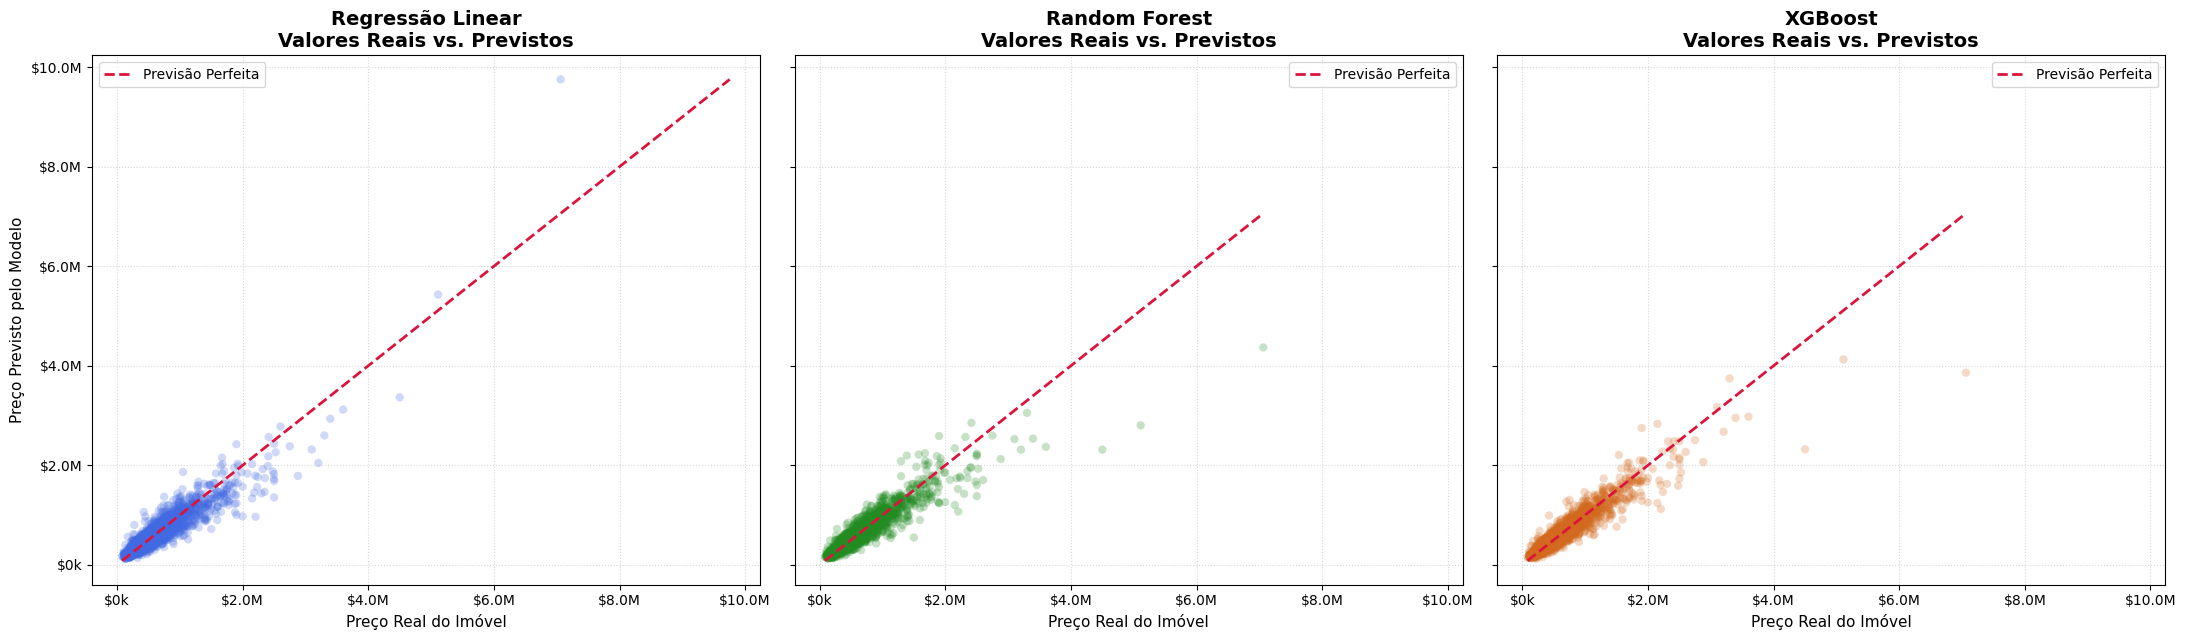

In [38]:
# V2
# Gerar as predições de todos os modelos na escala monetária real
y_test_real = np.expm1(y_test)
y_pred_lr = np.expm1(lr_model.predict(X_test))
y_pred_rf = np.expm1(rf_model.predict(X_test))
y_pred_xgb = np.expm1(xgb_model.predict(X_test))

# Config de plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True, sharex=True)

dados_plot = [
    ('Regressão Linear', y_pred_lr, 'royalblue'),
    ('Random Forest', y_pred_rf, 'forestgreen'),
    ('XGBoost', y_pred_xgb, 'chocolate')
]

for i, (nome, y_pred, cor) in enumerate(dados_plot):
    # Pontos reais vs Previstos
    sns.scatterplot(
        x=y_test_real, 
        y=y_pred, 
        ax=axes[i], 
        color=cor, 
        alpha=0.25, 
        edgecolor='none'
    )
    
    # Previsão perfeita
    limite_max = max(y_test_real.max(), y_pred.max())
    limite_min = min(y_test_real.min(), y_pred.min())
    axes[i].plot([limite_min, limite_max], [limite_min, limite_max], color='crimson', linestyle='--', linewidth=2, label='Previsão Perfeita')
    
    # Títulos e formatações
    axes[i].set_title(f'{nome}\nValores Reais vs. Previstos', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Preço Real do Imóvel', fontsize=11)
    if i == 0:
        axes[i].set_ylabel('Preço Previsto pelo Modelo', fontsize=11)
    
    # Formatação dos valores
    formatter = plt.FuncFormatter(lambda val, pos: f'${val*1e-6:.1f}M' if val >= 1e6 else f'${val*1e-3:.0f}k')
    axes[i].xaxis.set_major_formatter(formatter)
    axes[i].yaxis.set_major_formatter(formatter)
    
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Salvando o modelo

In [33]:
import json
import joblib 

caminho_pasta = '../models/v2/'
os.makedirs(caminho_pasta, exist_ok=True)

xgb_model = tuning.best_estimator_ 
caminho_modelo = os.path.join(caminho_pasta, 'modelo_regressao_v2.pkl')

joblib.dump(xgb_model, caminho_modelo)
print(f'Modelo salvo com sucesso em: {caminho_modelo}')

metricas_v2 = {
    'modelo': 'XGBoost_Otimizado',
    'r2_score': xgboost_orimizado_r2_best,
    'mae_usd': xgboost_orimizado_mae_best,
    'mse_usd': xgboost_orimizado_mse_best,
    'rmse_usd': xgboost_orimizado_rmse_best,
    'parametros': 'learning_rate=0.05, max_depth=6'}

caminho_metricas = os.path.join(caminho_pasta, 'metricas_v2.json')

with open(caminho_metricas, 'w', encoding='utf-8') as f:
    json.dump(metricas_v2, f, indent=4)
    
print(f'Métricas salvas com sucesso em: {caminho_metricas}')

Modelo salvo com sucesso em: ../models/v2/modelo_regressao_v2.pkl
Métricas salvas com sucesso em: ../models/v2/metricas_v2.json


# Comparativo

In [35]:
# V1
tabela_comparativa = pd.DataFrame.from_dict(metricas_modelos_v1, orient='index', columns=colunas)
tabela_comparativa = tabela_comparativa.reset_index().rename(columns={'index': 'Modelo'})
tabela_comparativa = tabela_comparativa.sort_values(by='MAE (US$)').reset_index(drop=True)
tabela_comparativa

,Modelo,R² (Treino),R² (Teste),MAE (US$),MSE (US$),RMSE (US$)
0,XGBoost (Otimizado),0.958052,0.900787,67014.438904,1.539880e+10,124091.910801
1,Ensemble (Voting),0.961902,0.900827,67105.240270,1.551639e+10,124564.800100
2,XGBoost (Nativo),0.927118,0.895385,69473.862288,1.579499e+10,125678.125035
3,Random Forest (Padrão),0.983786,0.885382,74362.116106,2.020927e+10,142159.306347
4,Random Forest (Otimizado),0.972129,0.885499,74568.562681,2.005555e+10,141617.636506
5,Regressão Linear,0.859091,0.857251,87854.561567,2.726488e+10,165120.800959


In [36]:
# V2
tabela_comparativa = pd.DataFrame.from_dict(metricas_modelos, orient='index', columns=colunas)
tabela_comparativa = tabela_comparativa.reset_index().rename(columns={'index': 'Modelo'})
tabela_comparativa = tabela_comparativa.sort_values(by='MAE (US$)').reset_index(drop=True)
tabela_comparativa

,Modelo,R² (Treino),R² (Teste),MAE (US$),MSE (US$),RMSE (US$)
0,XGBoost (Otimizado),0.964025,0.909329,60627.384596,1.382460e+10,117578.071159
1,Ensemble (Voting),0.967178,0.909073,60849.495336,1.391673e+10,117969.171702
2,XGBoost (Nativo),0.935583,0.903358,63243.635995,1.452422e+10,120516.482745
3,Random Forest (Otimizado),0.984431,0.898403,65717.825316,1.744661e+10,132085.604212
4,Random Forest (Padrão),0.985016,0.893975,67692.155520,1.713801e+10,130912.211915
5,Regressão Linear,0.876593,0.868847,77157.888221,1.767003e+10,132928.652607
